<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 5 - Likelihood and Parameter Estimation</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                Notebook author: <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Objectives
The objective of this TD is to understand how to compute the likelihood of a behavioral trajectory given a computational cognitive model. Using the Reinforcement Learning model that we implemented last time, we will:
- Define the notion of likelihood for a single action (simplified)
- Define the likelihood of a full sequence of actions (simplified model)
- Write a log likelihood method for the RLModel class
- Explore how changing the parameter values of an RLModel affects the likelihood of the behavior
- Implement Maximum Likelihood Estimation (MLE) to estimate the parameters of the model on behavioral data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pybads import BADS

from tests import test_rl_model_policy, test_likelihood_for_a_trajectory, test_log_likelihood_for_a_trajectory, test_rl_model_log_likelihood

%reload_ext autoreload
%autoreload 2

## Back to a simplified version of the Reinforcement Learning model
In the first part of this exercise, we will use a simplified version of the RLModel without a learning rule. This simplification allows us to get a good understanding of likelihood calculation before addressing q-value updates.

### Policy
Below is the `SimplifiedRLModel`, which has some of the methods of the `RLModel` class on which we worked last time. We need to re-write the policy method. As a reminder, the softmax policy works as follows:

At each trial, the agent selects the action with the highest q-value, but with some randomness governed by its exploration strategy. The probability of choosing action 1 is determined by the policy, modulated by the **temperature ($\tau$)** parameter. When $\tau \to 0^+$, the model exhibits no exploration and behaves greedily, always selecting the action it deems most rewarding.
$$
p_t = \frac{1}{1 + \exp(\frac{-(Q_t^{(1)} - Q_t^{(0)})}{\tau})}
$$
where:
- $p_t$ is the probability of choosing action 1 at trial $t$
- $Q_t^{(0)}$ and $Q_t^{(1)}$ are the q-values of actions 0 and 1 respectively, at trial $t$
- $\tau$ is the temperature

📝Implement the `policy` method in the `SimplifiedRLModel` class. Use the equation of the softmax rule given in the explantions.

>**_Note_**: In today's notebook, we introduce **type hinting**, a Python way of specifying a variable's data type. For example, if you look at the constructor below (`__init__()`), we indicate that the temperature must be given as a float argument (and not an integer, array, or something else). Type hinting is not mandatory in Python, but makes your code easier to understand and use.
>
>The syntax is as follows: `temperature: float`. The variable name is on the left, and the data type is on the right.

In [2]:
# Solution
class SimplifiedRLModel:
    def __init__(self, temperature: float):
        self.temperature = temperature
        self.q_values = np.array([0.5, 0.5]) # At t=0, both arms are assumed to have a value of 0.5

    def set_q_values(self, q_0: float, q_1: float):
        self.q_values = np.array([q_0, q_1])
        return self

    def policy(self):
        # Complete this code
        prob = 1 / (1 + np.exp(-(self.q_values[1] - self.q_values[0]) / self.temperature))
        return prob

Run this cell to test your implementation.

In [3]:
test_rl_model_policy(SimplifiedRLModel)

✅ OK 👌


### Likelihood for an individual action

We will go step by step.

Let's first define the likelihood of our model's parameters for only one action. The **likelihood** is defined as a function of the **parameter $\tau$**, and tells us how likely it is that a model parametrized by this $\tau$ would select **action $a_t$**. More formally it is the **conditional probability** that the model would choose $a_t$, given that we have set its temperature to $\tau$:
$$
\mathcal{L}(\tau; a_t) = p(a_t | \tau)
$$

📝Implement the `likelihood_one_action` function that takes an **instantiated `SimplifiedRLModel` model** (i.e. whose temperature has been set), and an **action** (0 or 1) as inputs, and returns the likelihood that the model would have picked the action.

In [4]:
# Solution
def likelihood_one_action(model: SimplifiedRLModel, action: int) -> float:
    p = model.policy()
    if action == 1:
        return p
    else:
        return 1 - p

📝Call your function with different parametrization of the model and both actions (0 and 1) to see if it returns the expected values.
You can also try to set different Q-values by using the `set_q_values()` method.

In [5]:
simple_model = SimplifiedRLModel(0.5).set_q_values(0.7, 0.5)
print(f"p(a=0|tau) = {likelihood_one_action(simple_model, 1):.3f}")
print(f"p(a=1|tau) = {likelihood_one_action(simple_model, 0):.3f}")

p(a=0|tau) = 0.401
p(a=1|tau) = 0.599


💭Among parameters and latent variables of the RLModel, list all the ones that influence the likelihood of an action.

_Your answer here_

### Likelihood of a full behavioral trajectory (Simplified model)

❓But how do we compute the likelihood of a **sequence** of actions, i.e. $a_1, a_2, ..., a_T$

Now that we have an understanding of what likelihood means for a single action, we can extend this to a full trajectory of actions. Take some time to think about how you would compute the likelihood of a full behavioral trajectory given a model. What would the mathematical formula look like?

💭Before you look at the explanations below, take fa few minutes to figure out, on a piece of paper, the likelihood formula for a full behavioral trajectory. Drawing on your current knowledge of probability and recalling concepts seen in class before you look at the answer will considerably boost your understanding. Ask for guidance if you are stuck or if you don't know where to start.

Yes, write it down! Really! 😁

### Likelihood for a full trajectory

To make things simple, we will again use our `SimplifiedRLModel` that doesn't process rewards, learn or update its Q-values between trials. In this case, the likelihood for a full trajectory can be simply defined as the **joint probability** of all the actions in the trajectory, given the model parameter.

In other words, it is the product of the likelihood of each action :
$$
\mathcal{L}(\tau; a_{1:T}) = \prod_{t=1}^{T} p(a_t | \tau)
$$

_Probability reminder:_ This product rule works only for independent events

📝 Complete the `likelihood_for_a_trajectory` function below, that now takes as a second argument a sequence of actions (in a 1-dimensional array)

__Note__: You can re-use your `likelihood_one_action` function in this new function

In [6]:
# Solution
def likelihood_for_a_trajectory(model: SimplifiedRLModel, actions: np.ndarray) -> float:
    likelihood = 1
    for action in actions:
        likelihood *= likelihood_one_action(model, action)
    return likelihood

Test your function

In [7]:
test_likelihood_for_a_trajectory(likelihood_for_a_trajectory)

✅ OK 👌


📝 Run your function on a sequence of 10 random actions. Try to see what happens if you increase the number of trials.

In [8]:
actions = np.random.choice([0, 1], size=10)
likelihood_for_a_trajectory(SimplifiedRLModel(0.5), actions)

np.float64(0.0009765625)

In [9]:
actions = np.random.choice([0, 1], size=100)
likelihood_for_a_trajectory(SimplifiedRLModel(0.5), actions)

np.float64(7.888609052210118e-31)

💭Do notice what happens when we compute the joint probability of an increasing number of actions? Do you remember what is the workaround found by mathematicians to avoid this?

_Your answer here_

### Log likelihood for a trajectory
Now, rewrite your function to compute the **log likelihood** for a full trajectory. This is a common practice because the likelihood of a full trajectory can be very small and difficult to work with. By taking the log, we can transform the product into a sum, which is easier to work with and less prone to numerical errors.

And for a sequence of actions, the **product** of probabilities becomes a **sum** of **log** probabilities!
$$
\ell(\tau; a_{1:T}) = \sum_{t=1}^{T} \log p(a_t | \tau)
$$

In [10]:
# Solution
def log_likelihood_for_a_trajectory(model: SimplifiedRLModel, actions: np.ndarray) -> float:
    loglikelihood = 0
    for action in actions:
        loglikelihood += np.log(likelihood_one_action(model, action))
    return loglikelihood

Test your function

In [11]:
test_log_likelihood_for_a_trajectory(log_likelihood_for_a_trajectory)

✅ OK 👌


Run your function. Try to see what happens if you increase the number of trials.

In [12]:
# Solution
actions = np.random.choice([0, 1], size=10)
log_likelihood_for_a_trajectory(SimplifiedRLModel(0.5), actions)

np.float64(-6.931471805599453)

In [13]:
actions = np.random.choice([0, 1], size=1000)
log_likelihood_for_a_trajectory(SimplifiedRLModel(0.5), actions)

np.float64(-693.1471805599322)

## Full `RLModel` (with learning rule)
Now that you understand the notion of log likelihood for a behavior trajectory, we can get into the real stuff🔥. We will re-integrate the **learning rate** into the `RLModel`, so the model parameters are now $\theta = \{\alpha, \tau\}$. When simulated on a bandit task, a reinforcement learning model with proper learning ability is able to process rewards and update its Q-values over the trials. Therefore, action probabilities now also **depend on past rewards**, because rewards update Q-values, which then change future choice probabilities.

This means that we can no longer compute all $\log p(a_t|\theta)$ independently and sum them. We have to make the model "play" the task, one trial at a time, compute the likelihood, and update the Q-values before we move to the next trial.

### Log likelihood with a full trajectory while learning from rewards

More formally, in the calculation of the log likelihood, the probability of choosing each action $a_t$ is now **conditioned** on the **parameters ($\theta$)** AND the **rewards ($r_{1:t-1}$)** that were received up to trial $t$:

$$
\ell(\theta; a_{1:T}) = \sum_{t=1}^{T} p(a_t | \theta, $r_{1:t-1})
$$

_Reminder:_ Now that we have more than one parameter, a common convention is to use the variable $\theta$ to represent ALL the **free parameters** in your model (here, $\theta = \{\alpha, \tau\}$)


Calculating each $p(a_t|\theta, r_{1:t-1})$ while taking into consideration the dependency to past trials requires thaw we loop through the trials, just like we did in last week's `simulate()` method, except that now we need to compute the log likelihood at each loop iteration.

To make things more handy, we will implement the log likelihood function as a method of the `RLModel` class. We will reuse the same class as the one you implemented during the last TD. Its `policy` and `update` methods, which we will need today, are already provided.

📝Write the `log_likelihood()` method in the `RLModel` class. This method should take as input a sequence of actions and a sequence of rewards and return the log likelihood of the full trajectory.

In [14]:
class RLModel:
    def __init__(self, learning_rate: float, temperature: float):
        self.learning_rate = learning_rate
        self.temperature = temperature
        self.q_values = np.array([0.5, 0.5])

    def policy(self):
        np.seterr(over='ignore') # Silence the warning for overflow
        prob = 1 / (1 + np.exp(-(self.q_values[1] - self.q_values[0]) / self.temperature))
        np.seterr(over='warn')
        return prob

    def update(self, action: int, reward: float):
        td_error = reward - self.q_values[action]
        self.q_values[action] += self.learning_rate * td_error

    def log_likelihood(self, actions: np.ndarray, rewards: np.ndarray) -> float:
        self.reset()
        # Your code here
        loglikelihood = 0
        for action, reward in zip(actions, rewards):
            prob_a1 = self.policy()
            prob_chosen_action = prob_a1 if action == 1 else 1 - prob_a1
            loglikelihood += np.log(prob_chosen_action)
            self.update(action, reward)
        return loglikelihood

    def reset(self):
        self.q_values = np.array([0.5, 0.5])

    def __repr__(self):
        return f'RLModel(lr={self.learning_rate: .3f}, t={self.temperature: .3f})'

Try your function manually to see if it seems to work

In [15]:
n_trials = 40
actions = np.random.choice([0, 1], size=n_trials)
rewards = np.random.randn(n_trials)
model = RLModel(0.5, 0.5)

model.log_likelihood(actions, rewards)

np.float64(-36.11009304242799)

Test your function with unit tests

In [16]:
test_rl_model_log_likelihood(RLModel)

✅ OK 👌


## Visualizing the likelihood on the parameter space

To move one step toward parameter optimization, let's visualize how the likelihood varies over the model's **parameter space**. For this, we will produce a **heatmap** on the range of possible values for learning rate and temperature.

First, let's load a sequence of actions and rewards that were previously simulated with an RLModel with a pre-defined learning rate and temperature. Your task is to guess what those values were.

In [17]:
actions = np.load('actions.npy')
rewards = np.load('rewards.npy')

💭 How many trials were simulated in this data?

In [18]:
# Solution
actions.shape, rewards.shape

((300,), (300,))

#### Specifying the search space

Then we will test `n_values`=40 different values for each parameter.

📝 Define the bounds that will be explored for each parameter. Try your best guess for now, you will be able to modify them later if necessary. Note that you can also explore a more restrictive range if you want.

In [19]:
# Solution
n_values = 40

lrs = np.linspace(0.1, 0.9, n_values)       # Specify lower and higher bounds for learning rate
temps = np.linspace(0.1, 0.5, n_values)     # Specify lower and higher bounds for temperature

#### Computing likelihood on the search space

The following code loops through all combinations of learning rates and temperatures, and computes the associated likelihood.

**Important:** We want to study the **likelihoods** here. Likelihoods are probabilities, which is much easier to interpret than log probabilities. So you need to take the output of the `log_likelihood()` method and convert it to into a (not log) likelihood.

📝 Fill in the missing parts indicated, with comments.


In [20]:
# Solution
likelihoods = pd.DataFrame()

for lr in lrs:
    for temp in temps:
        model = RLModel(lr, temp)
        likelihood = np.exp(model.log_likelihood(actions, rewards))
        likelihoods.loc[round(lr, 2), round(temp, 2)] = likelihood

📝 Make a heatmap with the likelihood values made in your DataFrame

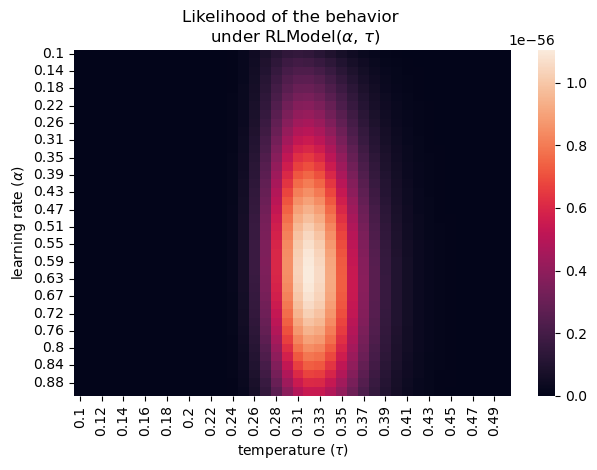

In [21]:
sns.heatmap(likelihoods)
plt.xlabel('temperature ($\\tau$)')
plt.ylabel('learning rate ($\\alpha$)')
plt.title('Likelihood of the behavior \n under RLModel($\\alpha$, $\\tau$)')
plt.tight_layout()

💭 Can you guess the learning rate and temperature of the model that simulated this behavioral trajectory?

You can adjust the range of parameter values that you explore if you wish to better see the point of maximum likelihood.

## 💪 Maximum Likelihood Estimation (MLE)

There is a way to automate the parameter search that you just did manually!

The goal of **Maximum Likelihood Estimation** is to find the set of parameters that maximize the likelihood, given the behavioral data. In other words, that's what we do when we say that we _"fit the model to a subject's data"_. If we write this mathematically, we want to find the parameters $\theta$ that maximize the likelihood of the data $D$ given the model $M$:
$$
\begin{align}
\hat{\theta}_\text{MLE} &= \arg \max_\theta \ell(\theta) \\
                        &= \arg \max_{\theta}\big(\log p(\text{behavior}| \theta, s )\big)
\end{align}
$$
with notation from the lecture slides:
- $\text{behavior}$ here stands for the sequence of actions $a_{1:T}$
- $s$ is the task parameters, in our case, the rewards received $r_{1:T-1}$

### Optimization routine
Now let's write the code that will find the set of parameters that maximize the likelihood of the behavioral data. For this, we can use a standard optimizer that will do the job for us. We will use BADS (Bayes Adaptive Direct Search). All we need to do is provide it with details about the range of values that we want to explore for each parameter, and a cost function that it needs to minimize. An optimization problem can either be framed as the _maximization_ or _minimization_ of an objective function, but it's standard for off-the-shelf optimizers to **minimize**. Since we have just defined a `model_performance` that we wish to **maximize**, we will have to add a minus sign to turn it into a `cost function` that we wish to **minimize**.

📝 Complete the `optimize_rl_model()` function:
1. Write the `cost_function`, that gives the "cost" associated with an RLModel with the given parameters:
    -  Instantiate an RLModel with the parameters given as arguments
    -  Compute the log likelihood of the actions passed to `fit_rl_model()` given this model and the `rewards` passed to `fit_rl_model()`
    -  Return the cost as a value that we wish to **minimize**

2. Complete the settings of the BADS optimizer, each of which is a list with two values, one for each parameter in the following order: \[lr, temp]. I let you think about what settings could be appropriate and we'll discuss it together. As a reference:
    - `x0` represent the typical value that you would expect for each parameter. It's the starting point of the optimization.
    - `lower_bounds` and `upper_bounds` specify the range of values that will be explored. In our case we have bounds of $[0, 1]$ for both parameters
    - `plausible_lower_bound` and `plausible_upper_bound` are more restrictive than the actual bounds and specify the range where we expect to find most solutions.

In [22]:
def fit_rl_model(actions: np.ndarray[int], rewards: np.ndarray[float],
                     verbose: bool = True):

    ##########################################################################
    # In python we can define functions inside functions.
    # Here we define the cost function that the BADS optimizer will try to minimize
    # It takes as input the parameters of the model and returns a value that we wish to minimize
    def cost_function(params):
        learning_rate, temperature = params
        model = RLModel(learning_rate, temperature)
        log_likelihood = model.log_likelihood(actions, rewards)
        return -log_likelihood
    ############################################################################

    optimizer = BADS(
        fun=cost_function,
        x0=[0.5, 0.1],
        lower_bounds=[0, 0],
        upper_bounds=[1, 1],
        plausible_lower_bounds=[0.2, 0.01],
        plausible_upper_bounds=[0.9, 0.5],
        options={
            'display': 'iter' if verbose else 'off'
        }
    )
    result = optimizer.optimize()
    optimal_params = {
        'learning_rate': result.x[0],
        'temperature': result.x[1]
    }
    return RLModel(**optimal_params)

📝 Run the optimization on the same actions and rewards as in the last exercise and see what value you find out!

In [23]:
actions = np.load('actions.npy')
rewards = np.load('rewards.npy')

fitted_model = fit_rl_model(actions, rewards)
fitted_model

Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         238.688               1                                 Uncertainty test
     0           6         130.562               1         Initial mesh            Initial points
     0          10         130.534             0.5         Refine grid             Train
     1          14         129.533             0.5     Successful search (ES-wcm)        
     1          17         129.391             0.5     Incremental search (ES-wcm)        
     1          22         129.187            0.25         Refine grid             Train
     2          25         128.872            0.25     Successful search (ES-wcm)        
     2          30         128.852            0.25     Incremental search (ES-ell)        
     2          34         128.852           0.125         Refine grid             
     3          36       

RLModel(lr= 0.617, t= 0.316)

## 💪 Optional exercise: Impact of the number of trials
Try to see what happens if you shorten the length of the sequence of actions and rewards. What parameters do you find? To what extent do you get values that are far away from the ones you get with the full trajectory?

In [24]:
n_trials = 10
partial_actions = actions[:n_trials]
partial_rewards = rewards[:n_trials]

fitted_model_partial = fit_rl_model(partial_actions, partial_rewards)
fitted_model_partial

Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         10.5654               1                                 Uncertainty test
     0           6          6.6443               1         Initial mesh            Initial points
     0          10         6.61291             0.5         Refine grid             Train
     1          13         6.59346             0.5     Incremental search (ES-wcm)        
     1          18         6.52629            0.25         Refine grid             Train
     2          20         6.52458            0.25     Incremental search (ES-wcm)        
     2          26         6.52309           0.125         Refine grid             
     3          29         6.51854           0.125     Incremental search (ES-wcm)        
     3          30         6.51498           0.125     Incremental search (ES-wcm)        
     3          34     

RLModel(lr= 0.116, t= 0.179)

Very different! Let's look at the heatmap to if the parameter are easily identifiable.

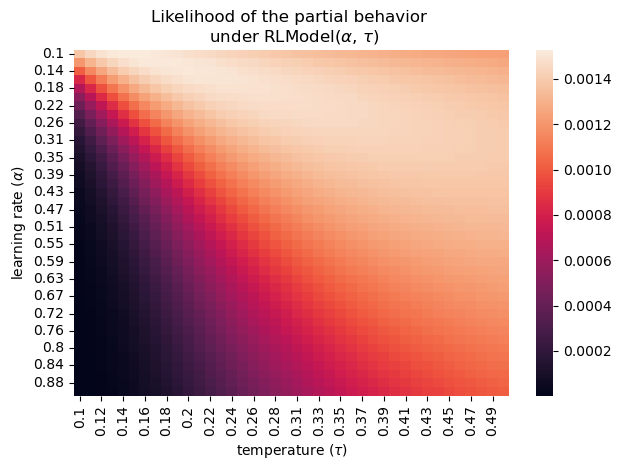

In [25]:
likelihoods = pd.DataFrame()

for lr in lrs:
    for temp in temps:
        model = RLModel(lr, temp)
        likelihood = np.exp(model.log_likelihood(partial_actions, partial_rewards))
        likelihoods.loc[round(lr, 2), round(temp, 2)] = likelihood

sns.heatmap(likelihoods)
plt.xlabel('temperature ($\\tau$)')
plt.ylabel('learning rate ($\\alpha$)')
plt.title('Likelihood of the partial behavior \n under RLModel($\\alpha$, $\\tau$)')
plt.tight_layout()